In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [ ]:
# Loading the trainig dataset into Pandas Dataframes
df = pd.read_csv("titanic.csv")
df

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,0
...,...,...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,0
1305,3,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,0
1306,3,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,0
1307,3,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,0


# **Exploratory data analysis**

In [ ]:
df.shape

(1309, 11)

In [ ]:
columns_list = list(df.columns)
columns_list


['pclass',
 'name',
 'sex',
 'age',
 'sibsp',
 'parch',
 'ticket',
 'fare',
 'cabin',
 'embarked',
 'survived']

In [ ]:
df.describe()

,pclass,age,sibsp,parch,fare,survived
count,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,1309.000000
mean,2.294882,29.881135,0.498854,0.385027,33.295479,0.381971
std,0.837836,14.413500,1.041658,0.865560,51.758668,0.486055
min,1.000000,0.166700,0.000000,0.000000,0.000000,0.000000
25%,2.000000,21.000000,0.000000,0.000000,7.895800,0.000000
50%,3.000000,28.000000,0.000000,0.000000,14.454200,0.000000
75%,3.000000,39.000000,1.000000,0.000000,31.275000,1.000000
max,3.000000,80.000000,8.000000,9.000000,512.329200,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   name      1309 non-null   object 
 2   sex       1309 non-null   object 
 3   age       1046 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   ticket    1309 non-null   object 
 7   fare      1308 non-null   float64
 8   cabin     295 non-null    object 
 9   embarked  1307 non-null   object 
 10  survived  1309 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 112.6+ KB


In [ ]:
df.isnull().sum()

pclass         0
name           0
sex            0
age          263
sibsp          0
parch          0
ticket         0
fare           1
cabin       1014
embarked       2
survived       0
dtype: int64

In [ ]:
df.duplicated().sum()

0

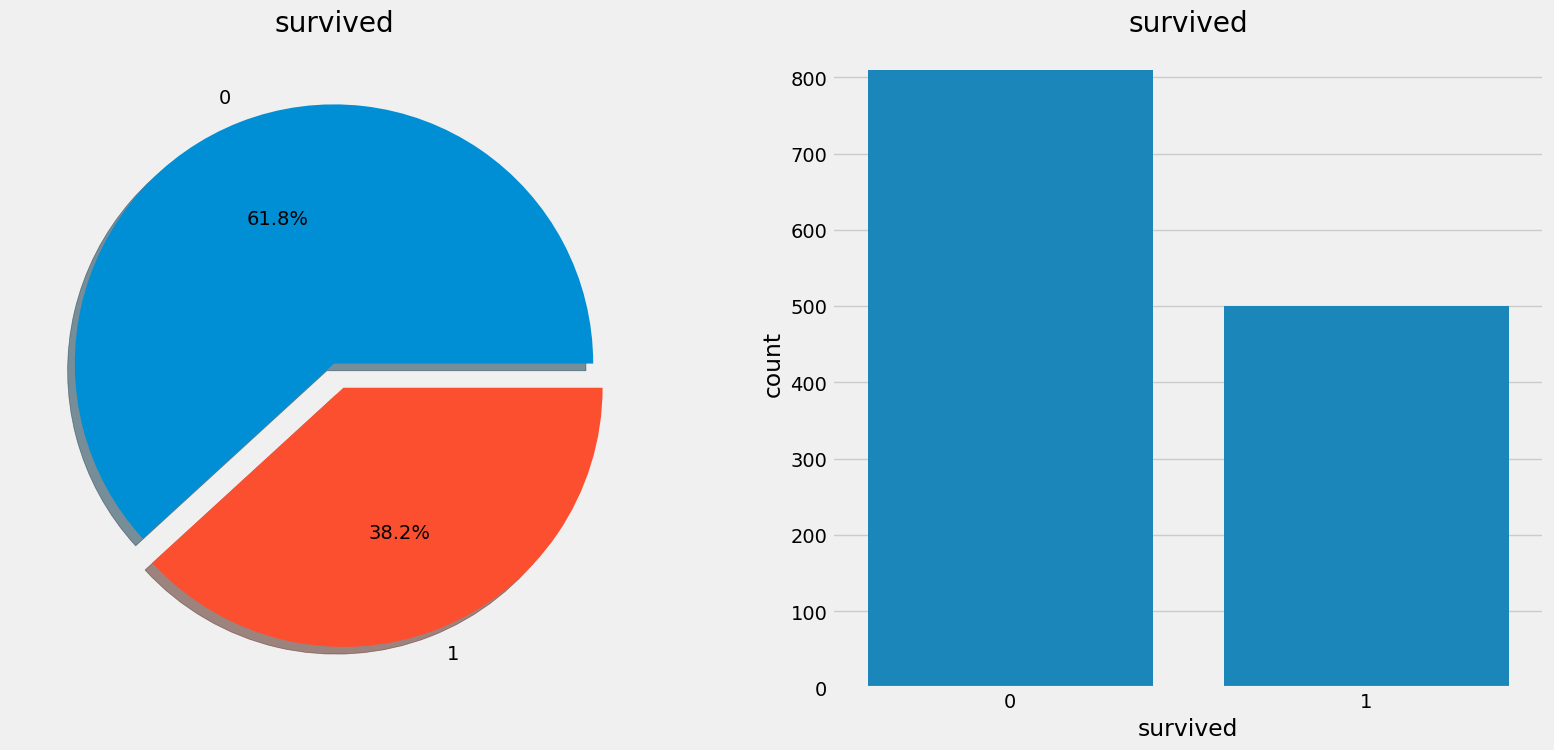

In [ ]:
f,ax=plt.subplots(1,2,figsize=(18,8))
df['survived'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True)
ax[0].set_title('survived')
ax[0].set_ylabel('')
sns.countplot(x='survived',data=df,ax=ax[1])
ax[1].set_title('survived')
plt.show()

# **Explore categorical variables**

In [ ]:
# find categorical variables
categorical = [var for var in df.columns if df[var].dtype=='O']
print('There are {} categorical variables\n'.format(len(categorical)))
print('The categorical variables are :\n\n', categorical)

There are 5 categorical variables

The categorical variables are :

 ['name', 'sex', 'ticket', 'cabin', 'embarked']


In [ ]:
# view the categorical variables
df[categorical].head()

,name,sex,ticket,cabin,embarked
0,"Allen, Miss. Elisabeth Walton",female,24160,B5,S
1,"Allison, Master. Hudson Trevor",male,113781,C22 C26,S
2,"Allison, Miss. Helen Loraine",female,113781,C22 C26,S
3,"Allison, Mr. Hudson Joshua Creighton",male,113781,C22 C26,S
4,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,113781,C22 C26,S


In [ ]:
# check missing values in categorical variables
df[categorical].isnull().sum()

name           0
sex            0
ticket         0
cabin       1014
embarked       2
dtype: int64

In [ ]:
# view frequency counts of values in categorical variables
for var in categorical:
    print(df[var].value_counts())

name
Connolly, Miss. Kate             2
Kelly, Mr. James                 2
Allen, Miss. Elisabeth Walton    1
Ilmakangas, Miss. Ida Livija     1
Ilieff, Mr. Ylio                 1
                                ..
Hart, Miss. Eva Miriam           1
Harris, Mr. Walter               1
Harris, Mr. George               1
Harper, Rev. John                1
Zimmerman, Mr. Leo               1
Name: count, Length: 1307, dtype: int64
sex
male      843
female    466
Name: count, dtype: int64
ticket
CA. 2343    11
1601         8
CA 2144      8
PC 17608     7
347077       7
            ..
373450       1
2223         1
350046       1
3101281      1
315082       1
Name: count, Length: 929, dtype: int64
cabin
C23 C25 C27        6
G6                 5
B57 B59 B63 B66    5
F4                 4
F33                4
                  ..
C132               1
E60                1
B52 B54 B56        1
C49                1
F38                1
Name: count, Length: 186, dtype: int64
embarked
S    914
C    27

In [ ]:
# view frequency distribution of categorical variables
for var in categorical:
    frequency_distribution = df[var].value_counts() / float(len(df))
    print(f"Frequency distribution for {var}:")
    print(frequency_distribution, "\n")

Frequency distribution for name:
name
Connolly, Miss. Kate             0.001528
Kelly, Mr. James                 0.001528
Allen, Miss. Elisabeth Walton    0.000764
Ilmakangas, Miss. Ida Livija     0.000764
Ilieff, Mr. Ylio                 0.000764
                                   ...   
Hart, Miss. Eva Miriam           0.000764
Harris, Mr. Walter               0.000764
Harris, Mr. George               0.000764
Harper, Rev. John                0.000764
Zimmerman, Mr. Leo               0.000764
Name: count, Length: 1307, dtype: float64 

Frequency distribution for sex:
sex
male      0.644003
female    0.355997
Name: count, dtype: float64 

Frequency distribution for ticket:
ticket
CA. 2343    0.008403
1601        0.006112
CA 2144     0.006112
PC 17608    0.005348
347077      0.005348
              ...   
373450      0.000764
2223        0.000764
350046      0.000764
3101281     0.000764
315082      0.000764
Name: count, Length: 929, dtype: float64 

Frequency distribution for cabin:
ca

In [ ]:
# check for cardinality in categorical variables
for var in categorical:
    print(var, ' contains ', len(df[var].unique()), ' labels')

name  contains  1307  labels
sex  contains  2  labels
ticket  contains  929  labels
cabin  contains  187  labels
embarked  contains  4  labels


In [ ]:
# check missing values in categorical variables
df[categorical].isnull().sum()

name           0
sex            0
ticket         0
cabin       1014
embarked       2
dtype: int64

In [ ]:
# Calculate the percentage of missing values in the categorical variables
missing_values = df[categorical].isnull().sum()
percentage_missing = ((missing_values / len(df)) * 100).sort_values(ascending=False)[missing_values>0]
percentage_missing

cabin       77.463713
embarked     0.152788
dtype: float64

# **Analysing The Categorical Features**

# **Sex Feature**

In [ ]:
df.groupby(['sex','survived'])['survived'].count()

sex     survived
female  0           127
        1           339
male    0           682
        1           161
Name: survived, dtype: int64

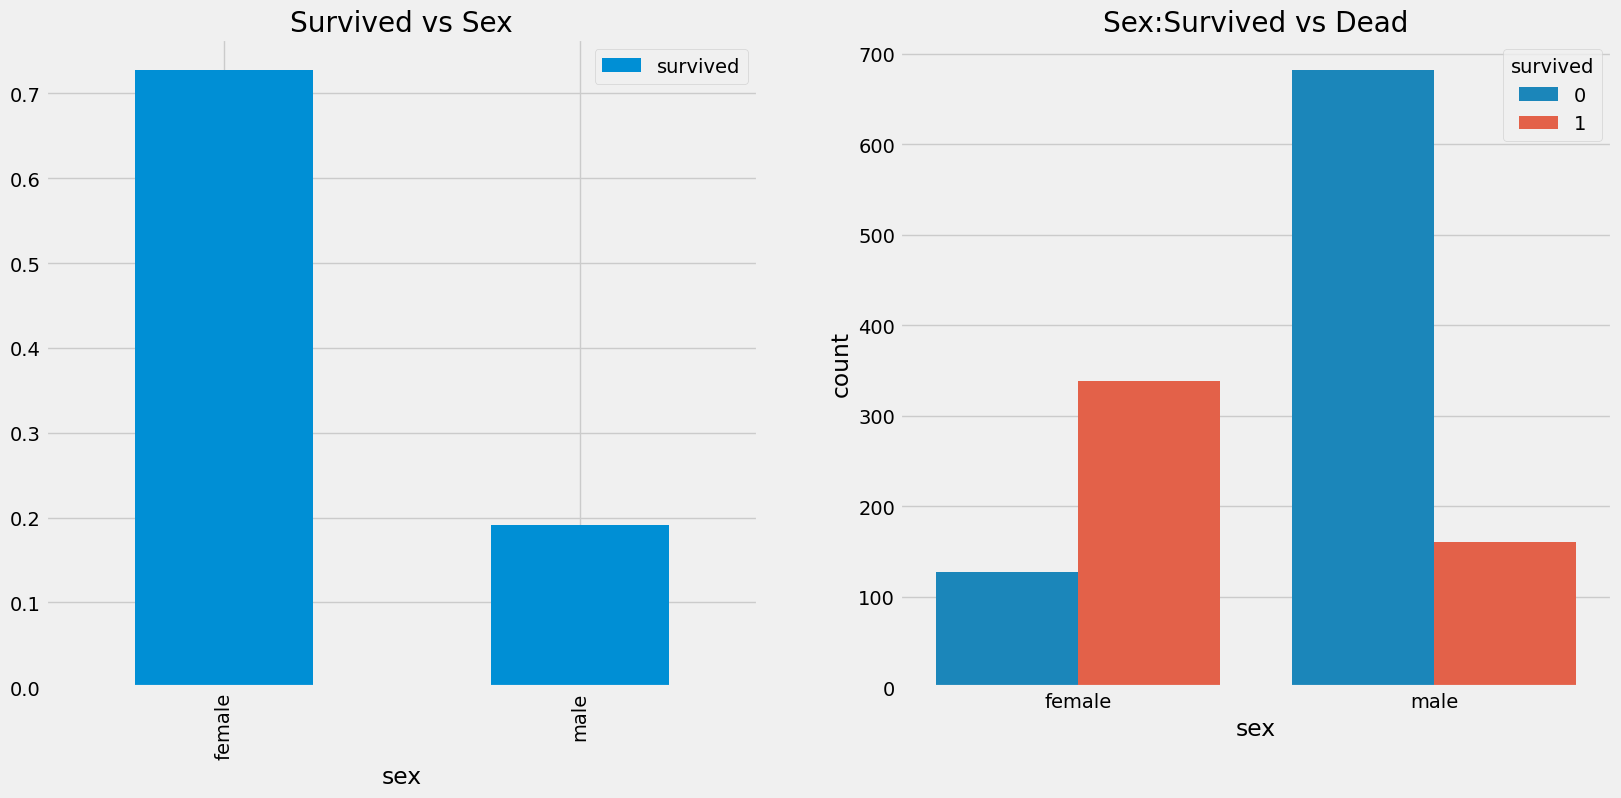

In [ ]:
f,ax=plt.subplots(1,2,figsize=(18,8))
df[['sex','survived']].groupby(['sex']).mean().plot.bar(ax=ax[0])
ax[0].set_title('Survived vs Sex')
sns.countplot(x='sex',hue='survived',data=df,ax=ax[1])
ax[1].set_title('Sex:Survived vs Dead')
plt.show()

# **Embarked Feature**

In [ ]:
pd.crosstab([df.embarked,df.pclass],[df.sex,df.survived],margins=True).style.background_gradient(cmap='summer_r')

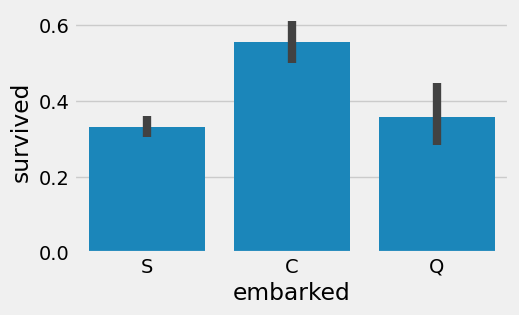

In [ ]:
# Create bar plot
sns.barplot(x='embarked', y='survived', data=df)
# Set the size of the plot
plt.gcf().set_size_inches(5, 3)
# Show the plot
plt.show()

# **Explore Numerical Variables**

In [ ]:
# find numerical variables
numerical = [var for var in df.columns if df[var].dtype!='O']
print('There are {} numerical variables\n'.format(len(numerical)))
print('The numerical variables are :', numerical)

There are 6 numerical variables

The numerical variables are : ['pclass', 'age', 'sibsp', 'parch', 'fare', 'survived']


In [ ]:
# view the numerical variables
df[numerical].head()

,pclass,age,sibsp,parch,fare,survived
0,1,29.0000,0,0,211.3375,1
1,1,0.9167,1,2,151.5500,1
2,1,2.0000,1,2,151.5500,0
3,1,30.0000,1,2,151.5500,0
4,1,25.0000,1,2,151.5500,0


In [ ]:
# check missing values in numerical variables
df[numerical].isnull().sum()

pclass        0
age         263
sibsp         0
parch         0
fare          1
survived      0
dtype: int64

In [ ]:
# Calculate the percentage of missing values in the numerical variables
missing_values = df[numerical].isnull().sum()
percentage_missing = ((missing_values / len(df)) * 100).sort_values(ascending=False)[missing_values>0]
percentage_missing

age     20.091673
fare     0.076394
dtype: float64

# **Analysing The Numerical Features**

# **Pclass Feature**

In [ ]:
pd.crosstab(df.pclass,df.survived,margins=True).style.background_gradient(cmap='summer_r')

survived,0,1,All
pclass,,,
1,123,200,323
2,158,119,277
3,528,181,709
All,809,500,1309


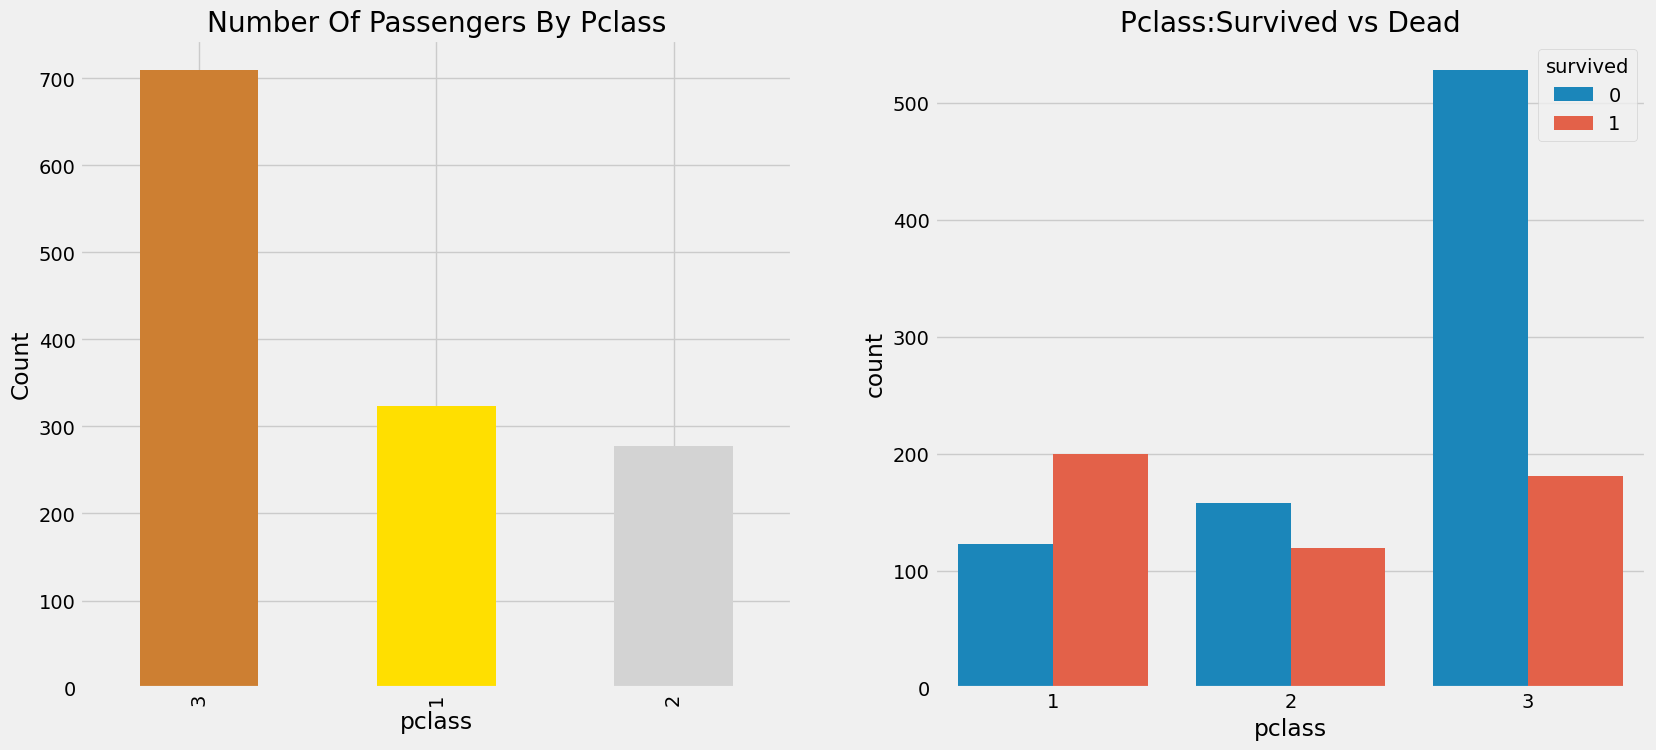

In [ ]:
f,ax=plt.subplots(1,2,figsize=(18,8))
df['pclass'].value_counts().plot.bar(color=['#CD7F32','#FFDF00','#D3D3D3'],ax=ax[0])
ax[0].set_title('Number Of Passengers By Pclass')
ax[0].set_ylabel('Count')
sns.countplot(x='pclass',hue='survived',data=df,ax=ax[1])
ax[1].set_title('Pclass:Survived vs Dead')
plt.show()

In [ ]:
pd.crosstab([df.sex,df.survived],df.pclass,margins=True).style.background_gradient(cmap='summer_r')

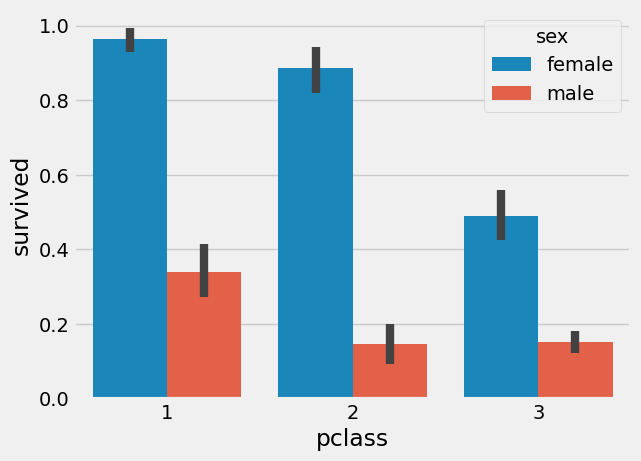

In [ ]:
sns.barplot(x='pclass', y='survived', hue='sex', data=df)
plt.show()

# **Age Feature**

In [ ]:
print('Oldest Passenger was of:',df['age'].max(),'Years')
print('Youngest Passenger was of:',df['age'].min(),'Years')
print('Average Age on the ship:',df['age'].mean(),'Years')

Oldest Passenger was of: 80.0 Years
Youngest Passenger was of: 0.1667 Years
Average Age on the ship: 29.8811345124283 Years


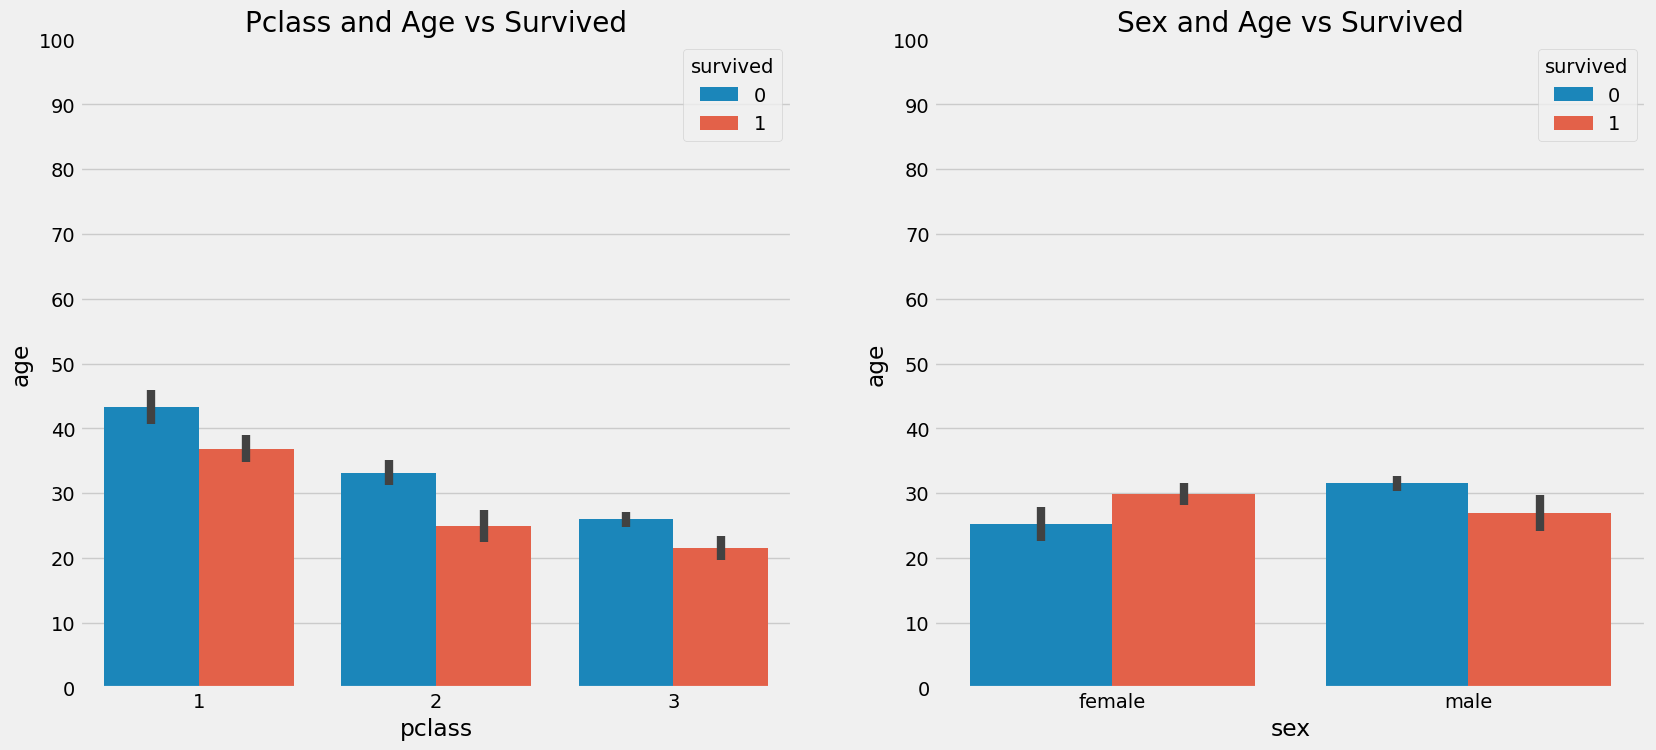

In [ ]:
f, ax = plt.subplots(1, 2, figsize=(18, 8))
# Bar plot for 'pclass' vs 'age' with 'survived' hue
sns.barplot(x="pclass", y="age", hue="survived", data=df, ax=ax[0])
ax[0].set_title('Pclass and Age vs Survived')
ax[0].set_yticks(range(0, 110, 10))
# Bar plot for 'sex' vs 'age' with 'survived' hue
sns.barplot(x="sex", y="age", hue="survived", data=df, ax=ax[1])
ax[1].set_title('Sex and Age vs Survived')
ax[1].set_yticks(range(0, 110, 10))
plt.show()

# **SibSip Feature**

In [ ]:
pd.crosstab([df.sibsp],df.survived).style.background_gradient(cmap='summer_r')

survived,0,1
sibsp,,
0,582,309
1,156,163
2,23,19
3,14,6
4,19,3
5,6,0
8,9,0


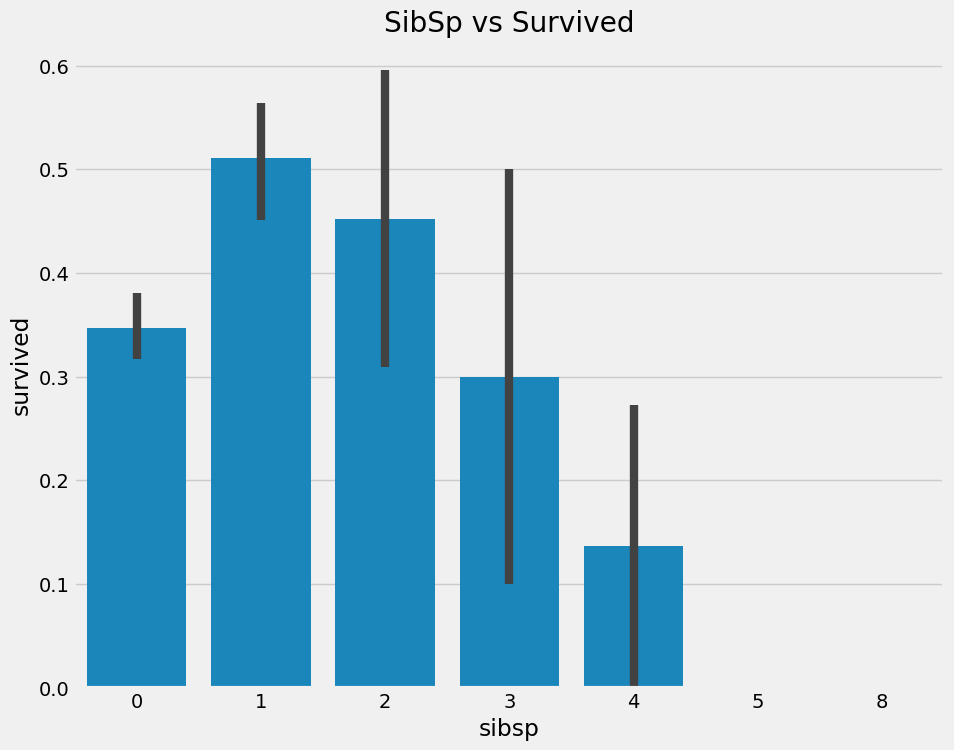

In [ ]:
# Create the bar plot
sns.barplot(x='sibsp', y='survived', data=df)
plt.title('SibSp vs Survived')
# Set the size of the plot
plt.gcf().set_size_inches(10, 8)
# Show the plot
plt.show()

# **Parch Feature**

In [ ]:
pd.crosstab(df.parch,df.pclass).style.background_gradient(cmap='summer_r')

pclass,1,2,3
parch,,,
0,242,206,554
1,50,43,77
2,27,25,61
3,2,3,3
4,2,0,4
5,0,0,6
6,0,0,2
9,0,0,2


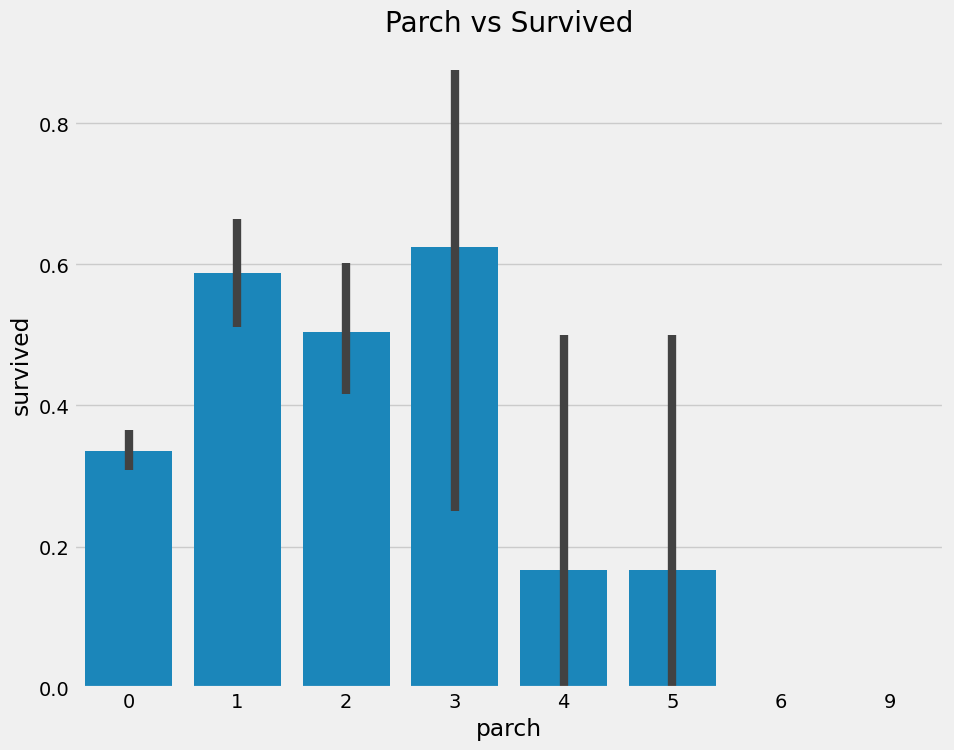

In [ ]:
# Create the bar plot
sns.barplot(x='parch', y='survived', data=df)
plt.title('Parch vs Survived')
# Set the size of the plot
plt.gcf().set_size_inches(10, 8)
# Show the plot
plt.show()

# **Date Preprocessing**

# **Fill Null Values In Age Feature**

In [ ]:
df['Initial']=0
for i in df:
    df['Initial']=df.name.str.extract('([A-Za-z]+)\.') #lets extract the Salutations

In [ ]:
pd.crosstab(df.Initial,df.sex).T.style.background_gradient(cmap='summer_r') #Checking the Initials with the Sex

Initial,Capt,Col,Countess,Don,Dona,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir
sex,,,,,,,,,,,,,,,,,,
female,0,0,1,0,1,1,0,1,0,0,260,2,1,0,197,2,0,0
male,1,4,0,1,0,7,1,0,2,61,0,0,0,757,0,0,8,1


In [ ]:
df['Initial'].replace(['Capt','Col','Countess','Don','Dona','Dr','Jonkheer','Lady','Major','Miss','Mlle','Mme','Rev','Sir'],['Mr','Other','Mrs','Mr','Mrs','Mr','Other','Mrs','Mr','Ms','Ms','Ms','Other','Mr'],inplace=True)

In [ ]:
pd.crosstab(df.Initial,df.sex).T.style.background_gradient(cmap='summer_r')

Initial,Master,Mr,Mrs,Ms,Other
sex,,,,,
female,0,1,200,265,0
male,61,769,0,0,13


In [ ]:
df.groupby('Initial')['age'].mean()

Initial
Master     5.482704
Mr        32.545531
Mrs       37.046243
Ms        21.834502
Other     44.923077
Name: age, dtype: float64

In [ ]:
## Assigning the NaN Values with the Ceil values of the mean ages
df.loc[(df.age.isnull())&(df.Initial=='Mr'),'age']=33
df.loc[(df.age.isnull())&(df.Initial=='Mrs'),'age']=37
df.loc[(df.age.isnull())&(df.Initial=='Master'),'age']=5
df.loc[(df.age.isnull())&(df.Initial=='Ms'),'age']=22
df.loc[(df.age.isnull())&(df.Initial=='Other'),'age']=45

In [ ]:
df.age.isnull().any() #So no null values left finally

False

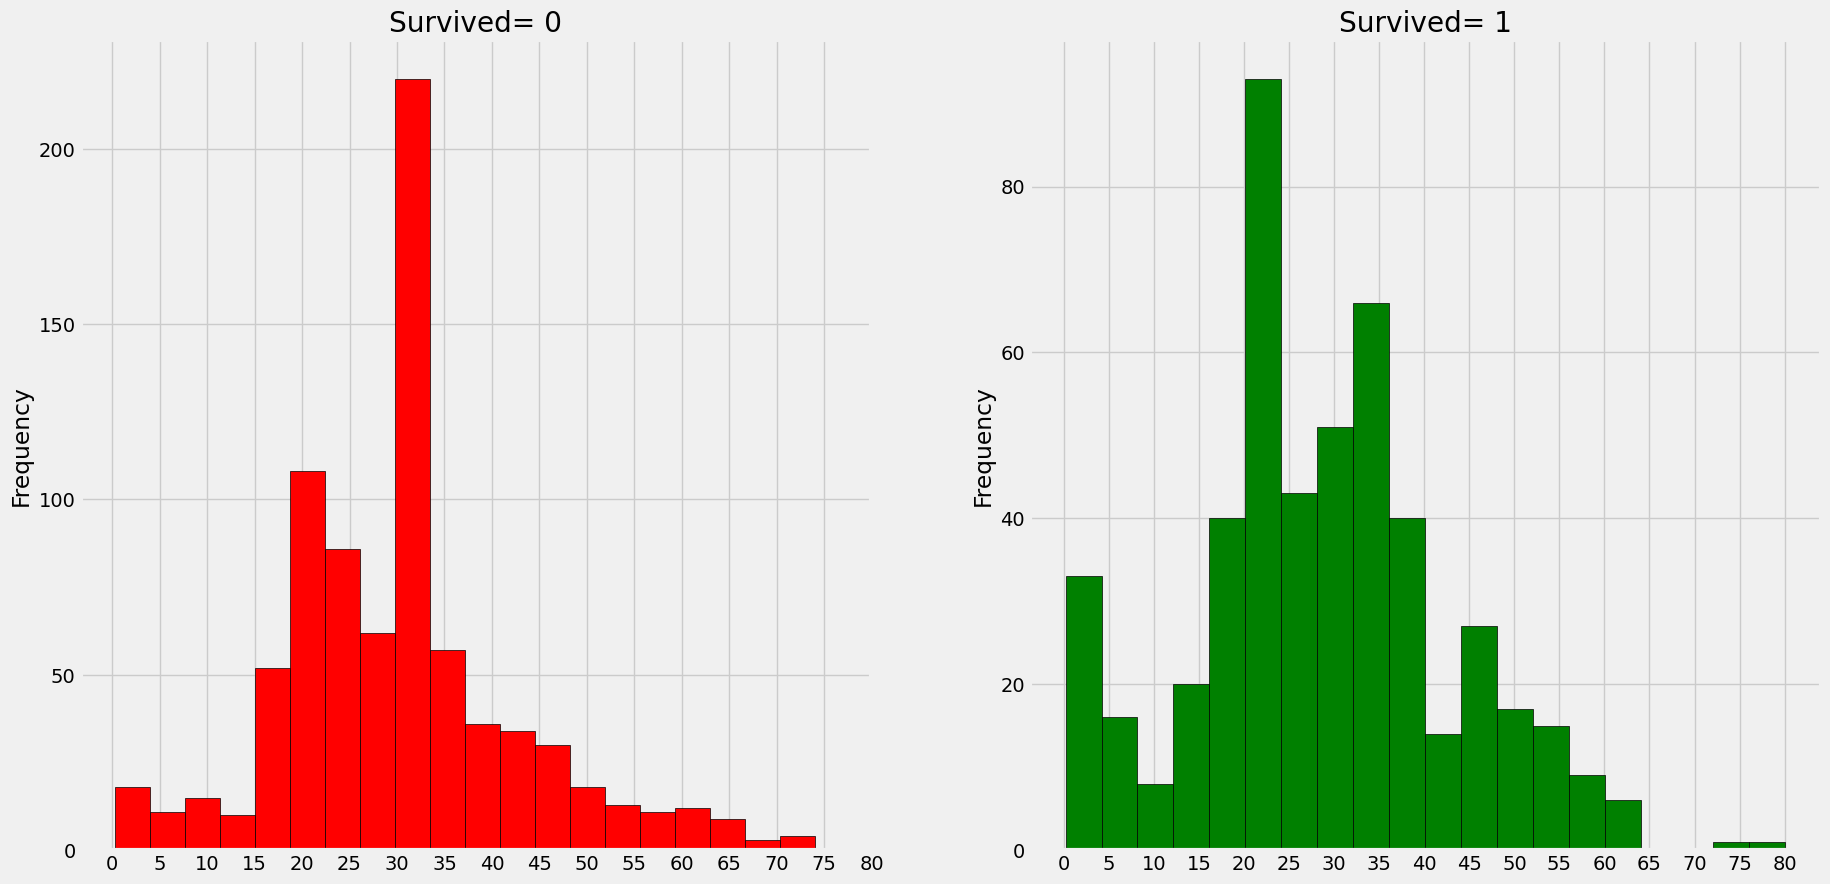

In [ ]:
f,ax=plt.subplots(1,2,figsize=(20,10))
df[df['survived']==0].age.plot.hist(ax=ax[0],bins=20,edgecolor='black',color='red')
ax[0].set_title('Survived= 0')
x1=list(range(0,85,5))
ax[0].set_xticks(x1)
df[df['survived']==1].age.plot.hist(ax=ax[1],color='green',bins=20,edgecolor='black')
ax[1].set_title('Survived= 1')
x2=list(range(0,85,5))
ax[1].set_xticks(x2)
plt.show()

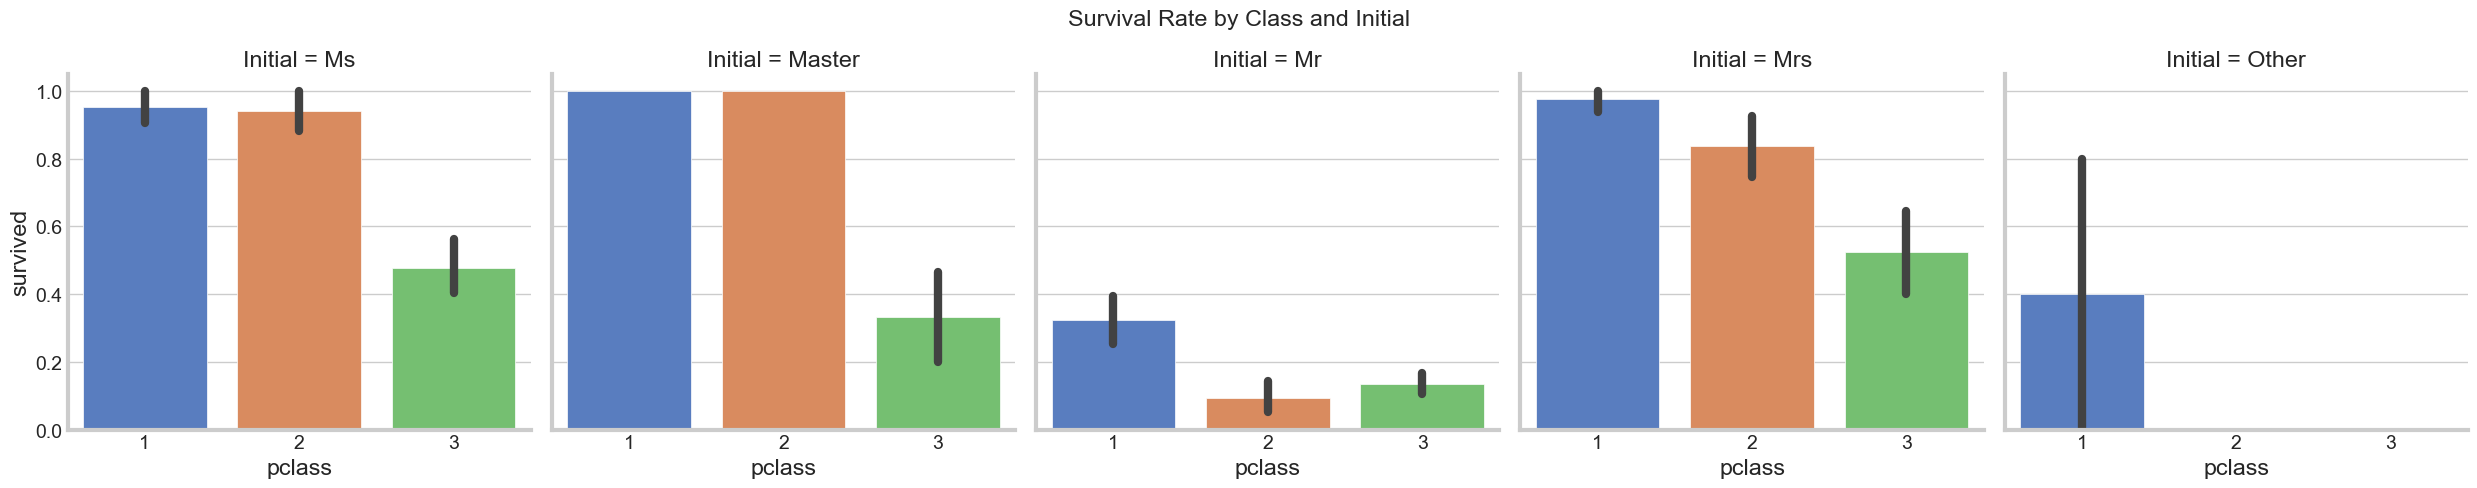

In [ ]:
# Creating the catplot with specific style, size, and other customizations
sns.set_style("whitegrid")  # Applying a grid style
sns.catplot(x='pclass', y='survived', col='Initial', data=df, kind='bar', palette='muted')

# Adding titles and labels
plt.subplots_adjust(top=0.85)  # Adjusting subplot for title space
plt.suptitle('Survival Rate by Class and Initial')  # Main title
plt.show()

# **Filling Null Values In Embarked**

In [ ]:
#maximum passengers boarded from Port S, we replace NaN with S
df['embarked'].fillna('S',inplace=True)

In [ ]:
df.embarked.isnull().any()

False

In [ ]:
df.isnull().sum()

pclass         0
name           0
sex            0
age            0
sibsp          0
parch          0
ticket         0
fare           1
cabin       1014
embarked       0
survived       0
Initial        0
dtype: int64

In [ ]:
df.drop(['name','ticket','cabin'],axis=1,inplace=True)
df

,pclass,sex,age,sibsp,parch,fare,embarked,survived,Initial
0,1,female,29.0000,0,0,211.3375,S,1,Ms
1,1,male,0.9167,1,2,151.5500,S,1,Master
2,1,female,2.0000,1,2,151.5500,S,0,Ms
3,1,male,30.0000,1,2,151.5500,S,0,Mr
4,1,female,25.0000,1,2,151.5500,S,0,Mrs
...,...,...,...,...,...,...,...,...,...
1304,3,female,14.5000,1,0,14.4542,C,0,Ms
1305,3,female,22.0000,1,0,14.4542,C,0,Ms
1306,3,male,26.5000,0,0,7.2250,C,0,Mr
1307,3,male,27.0000,0,0,7.2250,C,0,Mr


In [ ]:
# Drop rows with null values in the 'fare' column
df = df.dropna(subset=['fare'])

In [ ]:
df.isnull().sum()

pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
survived    0
Initial     0
dtype: int64

In [ ]:
# Calculate the correlation matrix
correlation_matrix = df.select_dtypes(include="number").corr()
correlation_matrix

,pclass,age,sibsp,parch,fare,survived
pclass,1.000000,-0.375666,0.061162,0.018615,-0.558629,-0.312122
age,-0.375666,1.000000,-0.221380,-0.140208,0.167533,-0.068322
sibsp,0.061162,-0.221380,1.000000,0.373485,0.160238,-0.028122
parch,0.018615,-0.140208,0.373485,1.000000,0.221539,0.082418
fare,-0.558629,0.167533,0.160238,0.221539,1.000000,0.244265
survived,-0.312122,-0.068322,-0.028122,0.082418,0.244265,1.000000


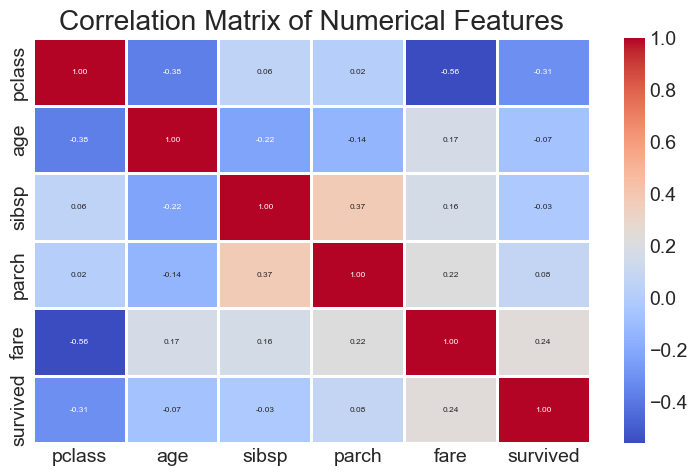

In [ ]:
plt.figure(figsize=(8, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1,annot_kws={"fontsize":6} )
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# **Encode categorical variables**

In [ ]:
df_encoded = pd.get_dummies(df, columns=['sex', 'embarked', 'Initial'])
df_encoded

,pclass,age,sibsp,parch,fare,survived,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,Initial_Master,Initial_Mr,Initial_Mrs,Initial_Ms,Initial_Other
0,1,29.0000,0,0,211.3375,1,True,False,False,False,True,False,False,False,True,False
1,1,0.9167,1,2,151.5500,1,False,True,False,False,True,True,False,False,False,False
2,1,2.0000,1,2,151.5500,0,True,False,False,False,True,False,False,False,True,False
3,1,30.0000,1,2,151.5500,0,False,True,False,False,True,False,True,False,False,False
4,1,25.0000,1,2,151.5500,0,True,False,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,14.5000,1,0,14.4542,0,True,False,True,False,False,False,False,False,True,False
1305,3,22.0000,1,0,14.4542,0,True,False,True,False,False,False,False,False,True,False
1306,3,26.5000,0,0,7.2250,0,False,True,True,False,False,False,True,False,False,False
1307,3,27.0000,0,0,7.2250,0,False,True,True,False,False,False,True,False,False,False


In [ ]:
# Loop through the columns in df_encoded
for column in df_encoded.columns:
  if df_encoded[column].dtype == 'bool':
        # Convert boolean to int
        df_encoded[column] = df_encoded[column].astype(int)

print(df)

      pclass     sex      age  sibsp  parch      fare embarked  survived  \
0          1  female  29.0000      0      0  211.3375        S         1   
1          1    male   0.9167      1      2  151.5500        S         1   
2          1  female   2.0000      1      2  151.5500        S         0   
3          1    male  30.0000      1      2  151.5500        S         0   
4          1  female  25.0000      1      2  151.5500        S         0   
...      ...     ...      ...    ...    ...       ...      ...       ...   
1304       3  female  14.5000      1      0   14.4542        C         0   
1305       3  female  22.0000      1      0   14.4542        C         0   
1306       3    male  26.5000      0      0    7.2250        C         0   
1307       3    male  27.0000      0      0    7.2250        C         0   
1308       3    male  29.0000      0      0    7.8750        S         0   

     Initial  
0         Ms  
1     Master  
2         Ms  
3         Mr  
4        Mrs

# **Remove Outliers Data**

In [ ]:
from scipy.stats import zscore
# Calculate Z-Score for each numerical column
z_scores = np.abs(zscore(df.select_dtypes(include="number")))
# Set a threshold for Z-scores (e.g., 3 standard deviations)
threshold = 3
# Identify outliers
outliers_z = (z_scores > threshold).any(axis=1)
outliers_data = df_encoded[outliers_z]
outliers_data

,pclass,age,sibsp,parch,fare,survived,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,Initial_Master,Initial_Mr,Initial_Mrs,Initial_Ms,Initial_Other
0,1,29.0,0,0,211.3375,1,1,0,0,0,1,0,0,0,1,0
9,1,71.0,0,0,49.5042,0,0,1,1,0,0,0,1,0,0,0
10,1,47.0,1,0,227.5250,0,0,1,1,0,0,0,0,0,0,1
11,1,18.0,1,0,227.5250,1,1,0,1,0,0,0,0,1,0,0
14,1,80.0,0,0,30.0000,1,0,1,0,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1179,3,33.0,1,9,69.5500,0,0,1,0,0,1,0,1,0,0,0
1180,3,37.0,1,9,69.5500,0,1,0,0,0,1,0,0,1,0,0
1210,3,40.0,1,4,27.9000,0,0,1,0,0,1,0,1,0,0,0
1211,3,45.0,1,4,27.9000,0,1,0,0,0,1,0,0,1,0,0


In [ ]:
# Remove outliers from the DataFrame and create a new DataFrame without outliers
df_no_outliers = df_encoded[~outliers_z]
df_no_outliers

,pclass,age,sibsp,parch,fare,survived,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,Initial_Master,Initial_Mr,Initial_Mrs,Initial_Ms,Initial_Other
1,1,0.9167,1,2,151.5500,1,0,1,0,0,1,1,0,0,0,0
2,1,2.0000,1,2,151.5500,0,1,0,0,0,1,0,0,0,1,0
3,1,30.0000,1,2,151.5500,0,0,1,0,0,1,0,1,0,0,0
4,1,25.0000,1,2,151.5500,0,1,0,0,0,1,0,0,1,0,0
5,1,48.0000,0,0,26.5500,1,0,1,0,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,14.5000,1,0,14.4542,0,1,0,1,0,0,0,0,0,1,0
1305,3,22.0000,1,0,14.4542,0,1,0,1,0,0,0,0,0,1,0
1306,3,26.5000,0,0,7.2250,0,0,1,1,0,0,0,1,0,0,0
1307,3,27.0000,0,0,7.2250,0,0,1,1,0,0,0,1,0,0,0


In [ ]:
df_no_outliers.drop(['sex_female','Initial_Master','Initial_Mr','Initial_Mrs','Initial_Ms','Initial_Other'],axis=1,inplace=True)
df_no_outliers

,pclass,age,sibsp,parch,fare,survived,sex_male,embarked_C,embarked_Q,embarked_S
1,1,0.9167,1,2,151.5500,1,1,0,0,1
2,1,2.0000,1,2,151.5500,0,0,0,0,1
3,1,30.0000,1,2,151.5500,0,1,0,0,1
4,1,25.0000,1,2,151.5500,0,0,0,0,1
5,1,48.0000,0,0,26.5500,1,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...
1304,3,14.5000,1,0,14.4542,0,0,1,0,0
1305,3,22.0000,1,0,14.4542,0,0,1,0,0
1306,3,26.5000,0,0,7.2250,0,1,1,0,0
1307,3,27.0000,0,0,7.2250,0,1,1,0,0


In [ ]:
df_no_outliers.rename(columns={'embarked_C': 'C', 'embarked_Q': 'Q','embarked_S':'S','sex_male':'male','sibsp':'sibSp'}, inplace=True)
df_no_outliers

,pclass,age,sibSp,parch,fare,survived,male,C,Q,S
1,1,0.9167,1,2,151.5500,1,1,0,0,1
2,1,2.0000,1,2,151.5500,0,0,0,0,1
3,1,30.0000,1,2,151.5500,0,1,0,0,1
4,1,25.0000,1,2,151.5500,0,0,0,0,1
5,1,48.0000,0,0,26.5500,1,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...
1304,3,14.5000,1,0,14.4542,0,0,1,0,0
1305,3,22.0000,1,0,14.4542,0,0,1,0,0
1306,3,26.5000,0,0,7.2250,0,1,1,0,0
1307,3,27.0000,0,0,7.2250,0,1,1,0,0


# feature scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Define the columns to be scaled
columns_to_scale = ['age', 'fare']

# Apply scaling to the selected columns only
df_no_outliers[columns_to_scale] = scaler.fit_transform(df_no_outliers[columns_to_scale])
df_no_outliers

,pclass,age,sibSp,parch,fare,survived,male,C,Q,S
1,1,0.011392,1,2,0.919227,1,1,0,0,1
2,1,0.027848,1,2,0.919227,0,0,0,0,1
3,1,0.453164,1,2,0.919227,0,1,0,0,1
4,1,0.377215,1,2,0.919227,0,0,0,0,1
5,1,0.726582,0,0,0.161039,1,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...
1304,3,0.217721,1,0,0.087672,0,0,1,0,0
1305,3,0.331645,1,0,0.087672,0,0,1,0,0
1306,3,0.400000,0,0,0.043823,0,1,1,0,0
1307,3,0.407595,0,0,0.043823,0,1,1,0,0


# **Test file preparations**

# reading the test file

In [ ]:
# Loading test dataset into Pandas Dataframes
test_df = pd.read_csv("test.csv")
test_df

,pclass,name,sex,age,sibSp,parch,ticket,fare,cabin,embarked
0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
5,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S
6,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q
7,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S
8,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C
9,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S


# preprocess the test file

In [ ]:
test_df.isnull().sum()

pclass       0
name         0
sex          0
age          1
sibSp        0
parch        0
ticket       0
fare         0
cabin       17
embarked     0
dtype: int64

In [ ]:
test_df.iloc[10]

pclass                     3
name        Ilieff, Mr. Ylio
sex                     male
age                      NaN
sibSp                      0
parch                      0
ticket                349220
fare                  7.8958
cabin                    NaN
embarked                   S
Name: 10, dtype: object

In [ ]:
# replace the missing value in row #10 with 33 years as he is 'Mr'
test_df['age'].fillna(33,inplace=True)

In [ ]:
sex = pd.get_dummies(test_df['sex'],drop_first=True)
embark = pd.get_dummies(test_df['embarked'])

In [ ]:
test_df = pd.concat([test_df,sex,embark],axis=1)
test_df = test_df.replace({True: 1, False: 0})
test_df

,pclass,name,sex,age,sibSp,parch,ticket,fare,cabin,embarked,male,C,Q,S
0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,1,0,1,0
1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,0,0,0,1
2,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,1,0,1,0
3,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,1,0,0,1
4,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,0,0,0,1
5,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S,1,0,0,1
6,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q,0,0,1,0
7,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S,1,0,0,1
8,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C,0,1,0,0
9,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S,1,0,0,1


In [ ]:
test_df.drop(['name','ticket','cabin','sex','embarked'],axis=1,inplace=True)
test_df

,pclass,age,sibSp,parch,fare,male,C,Q,S
0,3,34.5,0,0,7.8292,1,0,1,0
1,3,47.0,1,0,7.0000,0,0,0,1
2,2,62.0,0,0,9.6875,1,0,1,0
3,3,27.0,0,0,8.6625,1,0,0,1
4,3,22.0,1,1,12.2875,0,0,0,1
5,3,14.0,0,0,9.2250,1,0,0,1
6,3,30.0,0,0,7.6292,0,0,1,0
7,2,26.0,1,1,29.0000,1,0,0,1
8,3,18.0,0,0,7.2292,0,1,0,0
9,3,21.0,2,0,24.1500,1,0,0,1


In [ ]:
# scaling
scaler = MinMaxScaler()

# Define the columns to be scaled
columns_to_scale = ['age', 'fare']

# Apply scaling to the selected columns only
test_df[columns_to_scale] = scaler.fit_transform(test_df[columns_to_scale])
test_df

,pclass,age,sibSp,parch,fare,male,C,Q,S
0,3,0.418367,0,0,0.011017,1,0,1,0
1,3,0.673469,1,0,0.000000,0,0,0,1
2,2,0.979592,0,0,0.035706,1,0,1,0
3,3,0.265306,0,0,0.022088,1,0,0,1
4,3,0.163265,1,1,0.070250,0,0,0,1
5,3,0.000000,0,0,0.029562,1,0,0,1
6,3,0.326531,0,0,0.008360,0,0,1,0
7,2,0.244898,1,1,0.292294,1,0,0,1
8,3,0.081633,0,0,0.003045,0,1,0,0
9,3,0.142857,2,0,0.227856,1,0,0,1


# -------------------------------------------------------------------------------

# **Start to build our models!**

# Split the data into features (X) and target variable (y)

In [ ]:
X = df_no_outliers.drop('survived', axis=1)
y = df_no_outliers['survived']

# Splitting the data into training and testing sets

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)
X_train.shape, X_test.shape

((843, 9), (362, 9))

# **1)Naive Bayes**

# train a Gaussian Naive Bayes classifier on the training set

In [ ]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_pred = gnb.predict(X_test)
y_pred

array([0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1,

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix\n\n', cm)

Confusion matrix

 [[188  45]
 [ 43  86]]


In [ ]:
TP = cm[0,0]
TN = cm[1,1]
FP = cm[0,1]
FN = cm[1,0]
print('\nTrue Positives(TP) = ', TP)
print('\nTrue Negatives(TN) = ', TN)
print('\nFalse Positives(FP) = ', FP)
print('\nFalse Negatives(FN) = ', FN)


True Positives(TP) =  188

True Negatives(TN) =  86

False Positives(FP) =  45

False Negatives(FN) =  43


In [ ]:
from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
# Calculate precision, recall, and F1-score
report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

Accuracy: 0.7569060773480663
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       233
           1       0.66      0.67      0.66       129

    accuracy                           0.76       362
   macro avg       0.74      0.74      0.74       362
weighted avg       0.76      0.76      0.76       362



## plot the accuracy

Accuracy of Naive Bayes: 0.7569060773480663


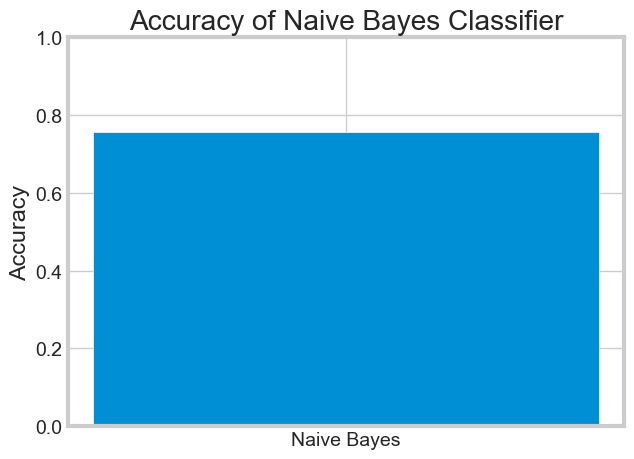

In [ ]:
# Calculate the accuracy of the Naive Bayes classifier
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy of Naive Bayes:", accuracy)

# Plot the accuracy
plt.bar(["Naive Bayes"], [accuracy])
plt.title("Accuracy of Naive Bayes Classifier")
plt.ylabel("Accuracy")
plt.ylim(0, 1)  # Set y-axis limit between 0 and 1
plt.show()

## **2)KNN**

In [ ]:
# import KNeighbors ClaSSifier from sklearn
from sklearn.neighbors import KNeighborsClassifier

# instantiate the model
knn = KNeighborsClassifier(n_neighbors=6)

# fit the model to the training set
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=6)

In [ ]:
y_pred = knn.predict(X_test)

y_pred

array([0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1,

In [ ]:
y_pred_train = knn.predict(X_train)

# calculate Accuracy

In [ ]:
from sklearn.metrics import accuracy_score
# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
print ("the model accuracy",accuracy)

the model accuracy 0.7845303867403315


KNN with euclidean distance metric:
Accuracy: 0.7845303867403315



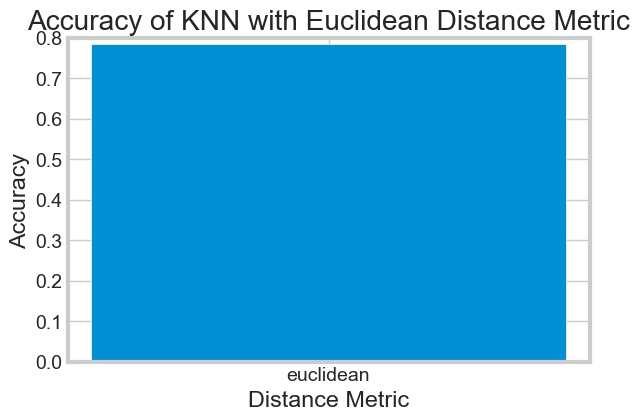

KNN with manhattan distance metric:
Accuracy: 0.7762430939226519



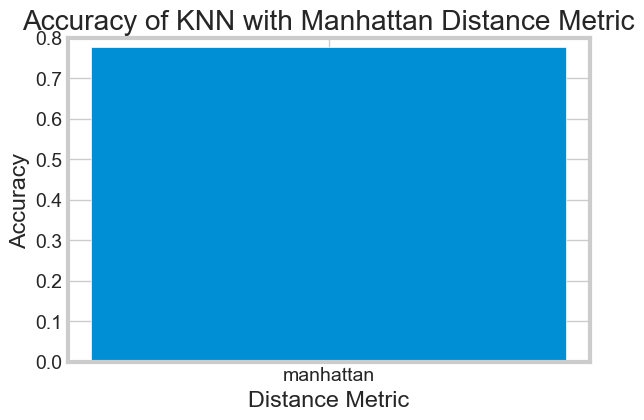

KNN with chebyshev distance metric:
Accuracy: 0.7983425414364641



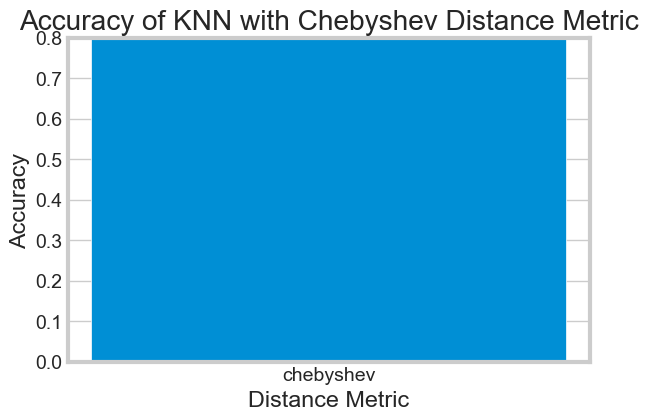

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Define a list of distance metrics to experiment with
distance_metrics = ['euclidean', 'manhattan', 'chebyshev']

for metric in distance_metrics:
    # Instantiate the KNN model with a specific distance metric
    knn = KNeighborsClassifier(n_neighbors=6, metric=metric)

    # Fit the model to the training set
    knn.fit(X_train, y_train)

    # Make predictions on the testing set
    y_pred = knn.predict(X_test)

    # Evaluate the model's performance
    accuracy = accuracy_score(y_test, y_pred)

    print(f"KNN with {metric} distance metric:")
    print("Accuracy:", accuracy)
    print()

    # Plot the accuracy for each distance metric
    plt.figure(figsize=(6, 4))
    plt.bar([metric], [accuracy])
    plt.xlabel('Distance Metric')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy of KNN with {metric.capitalize()} Distance Metric')
    plt.ylim(0, 0.8)  # Set y-axis limit between 0 and 0.8

    plt.show()


# Check for overfitting and underfitting

In [ ]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(knn.score(X_train, y_train)))

print('Test set score: {:.4f}'.format(knn.score(X_test,y_test)))

Training set score: 0.8066
Test set score: 0.7983


# print confusion matrix

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix\n\n',cm)


Confusion matrix

 [[207  26]
 [ 47  82]]


In [ ]:
TP = cm[0,0]
TN = cm[1,1]
FP = cm[0,1]
FN = cm[1,0]
print('\nTrue Positives(TP) = ', TP)
print('\nTrue Negatives(TN) = ', TN)
print('\nFalse Positives(FP) = ', FP)
print('\nFalse Negatives(FN) = ', FN)


True Positives(TP) =  207

True Negatives(TN) =  82

False Positives(FP) =  26

False Negatives(FN) =  47


In [ ]:
from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
# Calculate precision, recall, and F1-score
report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

Accuracy: 0.7983425414364641
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       233
           1       0.76      0.64      0.69       129

    accuracy                           0.80       362
   macro avg       0.79      0.76      0.77       362
weighted avg       0.80      0.80      0.79       362



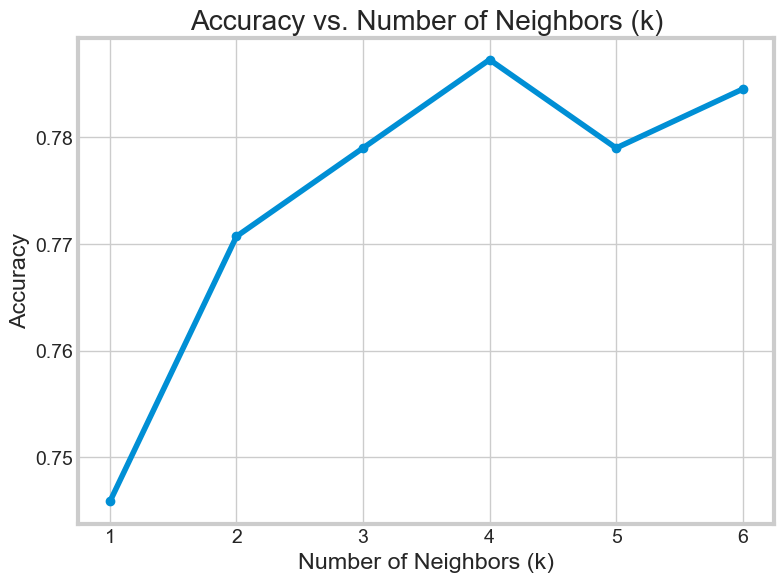

Best k (Elbow Method): 4


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Define a range of k values to search over
k_values = range(1, 7, 1)  # values of k from 1 to 7

# Initialize lists to store accuracy scores
accuracy_scores = []

# Iterate over each k value
for k in k_values:
    # Initialize the KNN classifier with the current k value
    knn = KNeighborsClassifier(n_neighbors=k)

    # Train the KNN classifier
    knn.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = knn.predict(X_test)

    # Calculate accuracy and store it
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)

# Plot the accuracy scores against k values
plt.figure(figsize=(8, 6))
plt.plot(k_values, accuracy_scores, marker='o', linestyle='-')
plt.title('Accuracy vs. Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Find the k value with the highest accuracy
best_k = k_values[np.argmax(accuracy_scores)]
print("Best k (Elbow Method):",best_k)


# **3)SVM**

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
classifier = SVC(probability=True, random_state=0)
classifier.fit(X_train, y_train)

SVC(probability=True, random_state=0)

In [ ]:
classifier.score(X_test, y_test)

0.8204419889502762

In [ ]:
classifier = SVC(kernel='linear', probability=True, random_state=0)
classifier.fit(X_train, y_train)
classifier.score(X_test, y_test)

0.8204419889502762

In [ ]:
from sklearn.model_selection import cross_validate
scores = cross_validate(classifier, X, y, cv=5)
print(scores['test_score'].mean())

0.7568464730290457


In [ ]:
from sklearn.model_selection import GridSearchCV

classifier= SVC(probability=True, random_state=0)

param_grid = {
    'C': [0.1, 0.5, 1, 5, 10],
    'gamma': [0.1, 0.5, 1, 5, 10],
    'kernel': ['linear', 'rbf', 'sigmoid']
}

grid_search = GridSearchCV(estimator=classifier, param_grid=param_grid, cv=5, verbose=2)
grid_search.fit(X, y) # Train the model 75 times with 75 different parameter combinations

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 75 candidates, totalling 375 fits
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.1s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.1s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.1s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.2s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.1s
[CV] END ...................C=0.1, gamma=0.1, kernel=sigmoid; total time=   0.1s
[CV] END ...................C=0.1, gamma=0.1, k

In [ ]:
print(grid_search.best_params_)

{'C': 0.1, 'gamma': 0.1, 'kernel': 'linear'}


In [ ]:
scores = cross_validate(best_model, X, y, cv=5)
print(scores['test_score'].mean())

0.7825726141078839


In [ ]:
model = SVC(kernel='linear', probability=True, random_state=0)

param_grid = {
    'C': [0.1,0.2, 0.5, 1, 1.5],
    'gamma': [0.001, 0.009, 0.098, 0.01, 0.1]
}

grid_search = GridSearchCV(estimator=classifier, param_grid=param_grid, cv=5, verbose=2)
grid_search.fit(X, y)

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV] END .................................C=0.1, gamma=0.001; total time=   0.1s
[CV] END .................................C=0.1, gamma=0.001; total time=   0.0s
[CV] END .................................C=0.1, gamma=0.001; total time=   0.0s
[CV] END .................................C=0.1, gamma=0.001; total time=   0.0s
[CV] END .................................C=0.1, gamma=0.001; total time=   0.0s
[CV] END .................................C=0.1, gamma=0.009; total time=   0.1s
[CV] END .................................C=0.1, gamma=0.009; total time=   0.1s
[CV] END .................................C=0.1, gamma=0.009; total time=   0.1s
[CV] END .................................C=0.1, gamma=0.009; total time=   0.1s
[CV] END .................................C=0.1, gamma=0.009; total time=   0.0s
[CV] END .................................C=0.1, gamma=0.098; total time=   0.0s
[CV] END .................................C=0.1

In [ ]:
print(grid_search.best_params_)

{'C': 1.5, 'gamma': 0.009}


In [ ]:
scores = cross_validate(best_model, X, y, cv=5)
print(scores['test_score'].mean())

0.7850622406639005


In [ ]:
classifier = best_model

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, classifier.predict(X_test)))

              precision    recall  f1-score   support

           0       0.85      0.87      0.86       233
           1       0.76      0.73      0.74       129

    accuracy                           0.82       362
   macro avg       0.81      0.80      0.80       362
weighted avg       0.82      0.82      0.82       362



Report 1:

Accuracy: 0.7569060773480663 F1-score (weighted avg): 0.76

Report 2:

Accuracy: 0.7983425414364641 F1-score (weighted avg): 0.79

Report 3:

Accuracy: 0.82 F1-score (weighted avg): 0.82

### Model 3 has the highest average accuracy and F1-score, making it the best performing model among the three models

### Model 2 follows with slight lower values, and Model 1 performs the poorest among

## **BONUS) Artificial Neural Networks (ANN)**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
model = tf.keras.models.Sequential()
model.add(Dense(32, activation = 'relu', input_shape = (9, )))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(1, activation='sigmoid'))


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,049 (8.00 KB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 0 (0.00 B)

## Training the ANN

In [ ]:
from keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
adam = Adam(0.1)
# Define the EarlyStopping callback to prevent overfitting.
early_stopping_monitor = EarlyStopping(min_delta=0.001, patience=10, monitor='val_loss', restore_best_weights=True)

In [ ]:
model.compile(optimizer='adam', loss = 'binary_crossentropy',metrics = ['accuracy'])


In [ ]:
# Training the ANN on the Training set

history = model.fit(x = X_train, y = y_train,
                    validation_data = (X_test, y_test),
                    callbacks=[early_stopping_monitor],
                    epochs=100)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.4778 - loss: 0.6943 - val_accuracy: 0.6464 - val_loss: 0.6454
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5965 - loss: 0.6511 - val_accuracy: 0.6464 - val_loss: 0.5827
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6144 - loss: 0.6146 - val_accuracy: 0.7072 - val_loss: 0.5408
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6846 - loss: 0.5833 - val_accuracy: 0.7818 - val_loss: 0.5074
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7551 - loss: 0.5504 - val_accuracy: 0.7901 - val_loss: 0.4931
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7329 - loss: 0.5584 - val_accuracy: 0.7901 - val_loss: 0.4829
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7728 - loss: 0.5216 - val_accuracy: 0.7845 - val_loss: 0.4817
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7837 - loss: 0.5062 - val_accuracy: 0.7873 - 

## Making the predictions and evaluating the model

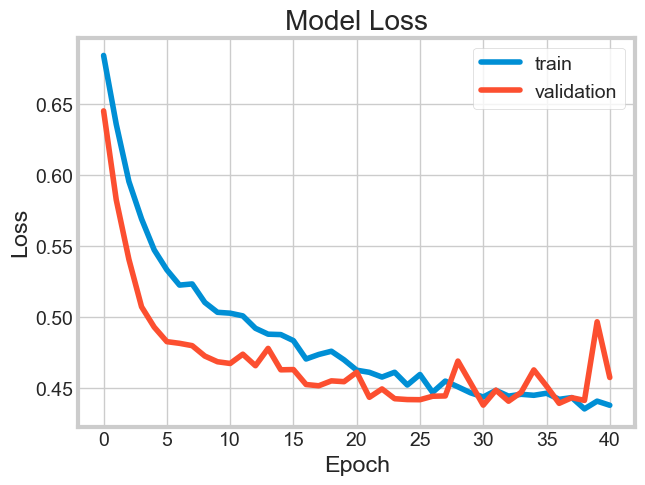

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()

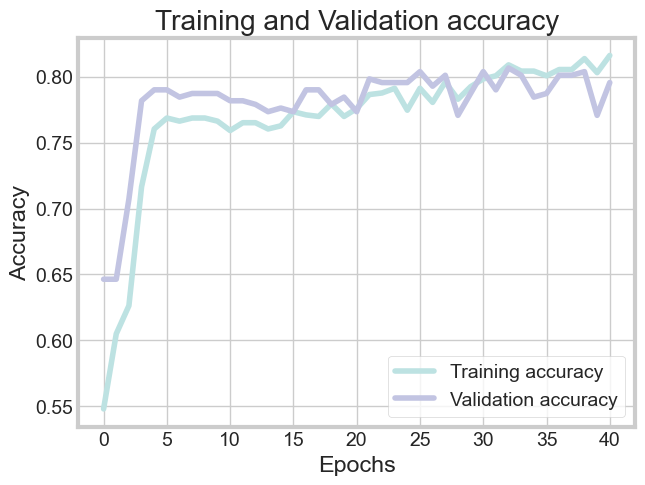

In [ ]:
history_df = pd.DataFrame(history.history)

plt.plot(history_df.loc[:, ['accuracy']], "#BDE2E2", label='Training accuracy')
plt.plot(history_df.loc[:, ['val_accuracy']], "#C2C4E2", label='Validation accuracy')

plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)
print(y_pred.astype(int))

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
[[0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [1]


### confusion matrix

In [ ]:
cf_matrix = confusion_matrix(y_test, y_pred)
print(cf_matrix)
accuracy_score(y_test,y_pred)

[[200  33]
 [ 38  91]]


0.8038674033149171

<Axes: >

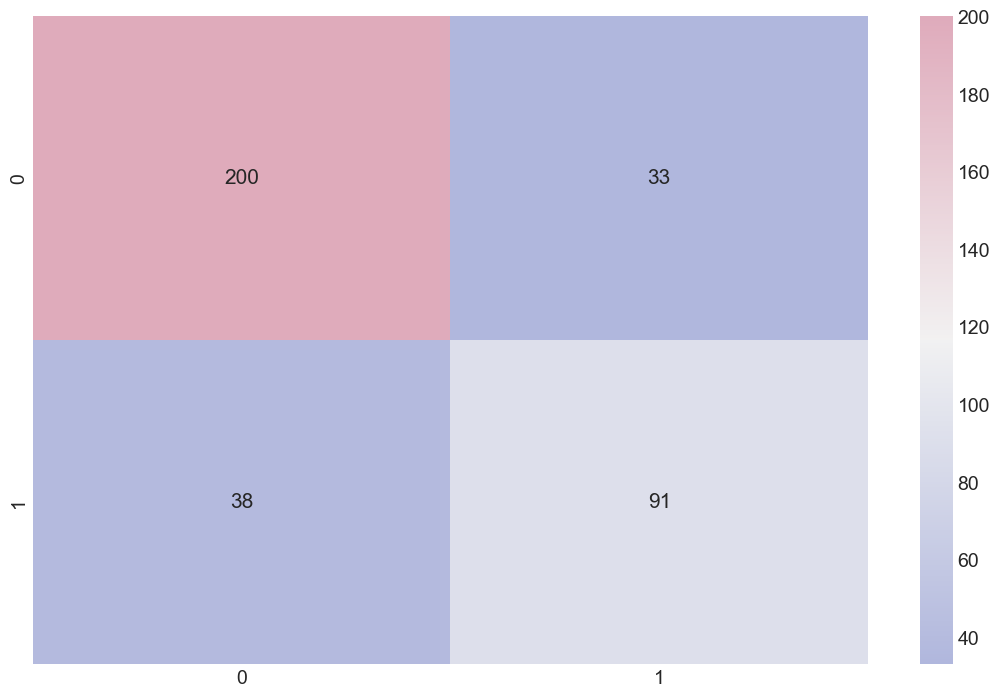

In [ ]:

cmap1 = sns.diverging_palette(260, -10, s=50, l=75, n=5, as_cmap=True)
plt.subplots(figsize=(12, 8))
cf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(cf_matrix, cmap=cmap1, annot=True, fmt='.0f', annot_kws={'size': 15})

### predictions on testfile

In [ ]:

predictions = model.predict(test_df)
predictions = (predictions > 0.5).astype(int)


df_predictions = pd.DataFrame(predictions, columns=["Survive"])

print(df_predictions)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
    Survive
0         0
1         0
2         0
3         0
4         0
5         0
6         1
7         0
8         1
9         0
10        0
11        0
12        1
13        0
14        1
15        1
16        0
17        0
18        0


done :)